In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import ( 
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)
sns.set_theme(style='darkgrid')


In [ ]:
# loading csv files

df_fake = pd.read_csv('Fake.csv')
df_true = pd.read_csv('True.csv')

print(df_fake.shape)
print(df_true.shape)

(23481, 4)
(21417, 4)


In [7]:
df_fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [8]:
df_true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [12]:
df_true['label'] = 1
df_fake['label'] = 0

df_fake.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [14]:
# concatenate both dataframes 
df = pd.concat([df_fake,df_true], ignore_index=True)

# shuffle the data so that 0 and 1 mix 
df = df.sample(frac=1,random_state=42).reset_index(drop=True)
df.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [18]:
print(df.shape)
print("\n", df['label'].value_counts().rename({1: 'REAL', 0: 'FAKE'}))


(44898, 5)

 label
FAKE    23481
REAL    21417
Name: count, dtype: int64


In [22]:
df[['title', 'text', 'subject', 'label']].head()

,title,text,subject,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,1


In [24]:
# feature engineering (combining title + text)
df['full_text'] = df['title'] + " " + df['text']
df.head()

,title,text,subject,date,label,full text,full_text
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0,Ben Stein Calls Out 9th Circuit Court: Committ...,Ben Stein Calls Out 9th Circuit Court: Committ...
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1,Trump drops Steve Bannon from National Securit...,Trump drops Steve Bannon from National Securit...
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1,Puerto Rico expects U.S. to lift Jones Act shi...,Puerto Rico expects U.S. to lift Jones Act shi...
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0,OOPS: Trump Just Accidentally Confirmed He Le...,OOPS: Trump Just Accidentally Confirmed He Le...
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1,Donald Trump heads for Scotland to reopen a go...,Donald Trump heads for Scotland to reopen a go...


In [25]:
X = df['full_text']
y = df['label'].values

In [27]:
X_train, X_test, y_train,y_test = train_test_split(X,y,random_state=42, stratify=y)

# TF=IDF Vectorizer initiaze 
tfidf = TfidfVectorizer(stop_words='english', max_features=10000, ngram_range=(1,2))

X_train_tf = tfidf.fit_transform(X_train)
X_test_tf = tfidf.transform(X_test)

print(X_train_tf.shape)

(33673, 10000)


In [29]:
nb_model = MultinomialNB(alpha=1)
nb_model.fit(X_train_tf,y_train)

y_pred = nb_model.predict(X_test_tf)
y_probs = nb_model.predict_proba(X_test_tf)[:,1]

In [31]:
# Accuracy & Scores

print(f"\nPERFORMANCE RESULTS")

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_probs)

print(f"Accuracy  : {acc*100:.2f}%")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")

print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['FAKE (0)', 'REAL (1)']))



PERFORMANCE RESULTS
Accuracy  : 95.29%
Precision : 0.9487
Recall    : 0.9527
F1 Score  : 0.9507
ROC-AUC   : 0.9889

--- Detailed Classification Report ---
              precision    recall  f1-score   support

    FAKE (0)       0.96      0.95      0.95      5871
    REAL (1)       0.95      0.95      0.95      5354

    accuracy                           0.95     11225
   macro avg       0.95      0.95      0.95     11225
weighted avg       0.95      0.95      0.95     11225



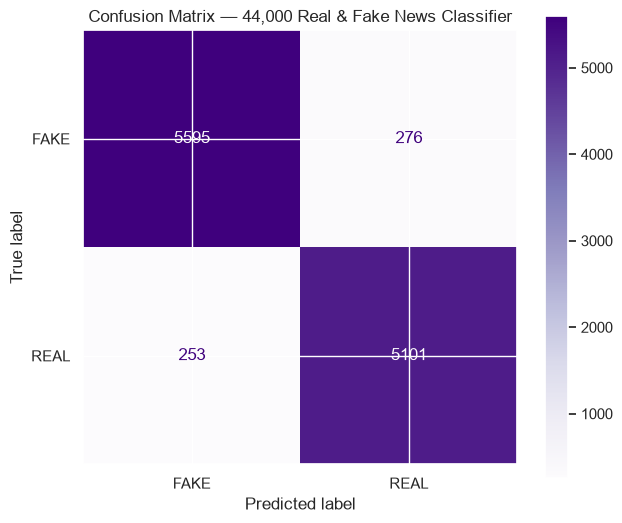

In [34]:
# Confusion Matrix Plot

fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['FAKE', 'REAL'])
disp.plot(cmap="Purples", ax=ax)
plt.title("Confusion Matrix — 44,000 Real & Fake News Classifier", fontsize=12)
plt.show()

In [36]:
def check_news(news_text):

    vec = tfidf.transform({news_text})

    pred = nb_model.predict(vec)[0]
    prob = nb_model.predict_proba(vec)[0]

    label = "Real News" if pred == 1 else "Fake News"
    confidence = np.max(prob) * 100

    print(f"\n📰 Input Article Snippet: '{news_text[:100]}...'")
    print(f"Prediction: {label} (Confidence: {confidence:.2f}%)")


check_news("WASHINGTON (Reuters) - The US President signed a new bipartisan tax bill into law today after approval in congress.")
check_news("BREAKING: Shocking alien autopsy photos leaked from secret government bunker in Nevada!")



📰 Input Article Snippet: 'WASHINGTON (Reuters) - The US President signed a new bipartisan tax bill into law today after approv...'
Prediction: Real News (Confidence: 99.03%)

📰 Input Article Snippet: 'BREAKING: Shocking alien autopsy photos leaked from secret government bunker in Nevada!...'
Prediction: Fake News (Confidence: 97.12%)


In [37]:
# Feature Names (Words) from TF-IDF
feature_names = np.array(tfidf.get_feature_names_out())

# Log Probabilities from Naive Bayes Model
# Class 0 = FAKE, Class 1 = REAL
fake_word_probs = nb_model.feature_log_prob_[0]
real_word_probs = nb_model.feature_log_prob_[1]

# Top 10 Words for FAKE News
top_fake_words = feature_names[np.argsort(fake_word_probs)[-10:]]

# Top 10 Words for REAL News
top_real_words = feature_names[np.argsort(real_word_probs)[-10:]]

print("FAKE News words:")
print(top_fake_words[::-1])

print("\n REAL News words:")
print(top_real_words[::-1])

FAKE News words:
['trump' 'video' 'clinton' 'obama' 'hillary' 'people' 'president' 'just'
 'said' 'like']

 REAL News words:
['said' 'trump' 'reuters' 'president' 'house' 'state' 'government'
 'republican' 'united' 'washington']
